# Metacatalog query browser

Browse Parquet catalogs under `CATALOG_DIR` (per-hour sources, LST-merged bands,
and the global metacatalog), pick one table, inspect it in a sortable/filterable
grid, find the nearest source to a sky coordinate, and — when viewing the
**metacatalog** — click a row to rematch that `meta_id` into LST/sources members
with consistency plots. Row clicks also update the nearest-source coordinate box
and center a **HiPS** sky view with band-colored catalog overlays (refreshes on pan/zoom).

Launch with `jupyter lab` (or your usual kernel that has `lwa-catalog[viz]`).
**Run cells in order.**


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import astropy.units as u
import numpy as np
import pandas as pd
import panel as pn
import param
from astropy.coordinates import SkyCoord

from lwa_catalog.io import read_table
from lwa_catalog.paths import CatalogLayout
from lwa_catalog.viz import (
    DebouncedAladinViewRefresh,
    aladin_view_center_fov,
    catalog_name_from_file,
    clear_trace_overlays,
    default_hips_survey,
    discover_local_hips_surveys,
    fetch_hips_surveys,
    format_coordinate_deg,
    hips_survey_url,
    overlay_catalog_by_band,
    overlay_trace_members,
    parse_coordinate,
)

# --- user configuration ---------------------------------------------------
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75/")

# HiPS tiles load in your web browser (not the Jupyter kernel).
# HIPS_LIST_SERVER — survey names from ``cgi-bin/list-hips.py`` (dropdown; kernel fetch).
# HIPS_SERVER — tile base URL passed to Aladin (browser fetch; can differ from list host).
# If the list fetch fails, scans CATALOG_DIR for HiPS ``properties`` directories.
# Example: list from pipeline, serve coadd tiles locally:
#   ssh -L 3005:lwacalim10:3005 lwacalim09
#   python -m http.server 8000 --directory /fast/claw/metacatalog_coadd2
#   HIPS_LIST_SERVER = "http://localhost:3005"
#   HIPS_SERVER = "http://localhost:8000"
HIPS_LIST_SERVER = "http://lwacalim10:3005"  # or http://localhost:3005 when SSH-tunneled
HIPS_SERVER = "http://localhost:3005"
DEFAULT_HIPS_SURVEY = "metacatalog_coaddR-0.75_full.hips"
SKY_FOV_DEG = 10
HIPS_VIEW_HEIGHT = 500
OVERLAY_MAX_SOURCES_DEFAULT = 500
OVERLAY_MAX_SOURCES_BOUNDS = (100, 1000)
SKY_SCREENSHOT_DIR = CATALOG_DIR / "sky_screenshots"

TABLE_HEIGHT = 420
TABLE_PAGE_SIZE = 50
DEFAULT_N_NEAREST = 3
MAX_TABLE_COLUMNS = 40  # keep Tabulator responsive for wide metacatalog rows

# Preferred column order when present (others follow alphabetically).
# Overridden at runtime by DISPLAY_COLUMN_PREFS if that file exists.
PREFERRED_COLUMNS = (
    "meta_id",
    "Source_id",
    "RA",
    "DEC",
    "Peak_flux",
    "Total_flux",
    "band",
    "lst_hour",
    "bands_present",
    "origin_band",
    "n_lst_contributions",
    "source_file",
)

DISPLAY_COLUMN_PREFS = Path.home() / ".config" / "lwa-catalog" / "metacatalog_query_columns.json"


def load_display_column_prefs(path: Path = DISPLAY_COLUMN_PREFS) -> list[str]:
    """Load saved display-column preference, else fall back to PREFERRED_COLUMNS."""
    try:
        raw = json.loads(path.read_text())
        cols = [str(c) for c in raw.get("columns", []) if str(c).strip()]
        if cols:
            return cols
    except (OSError, json.JSONDecodeError, AttributeError, TypeError):
        pass
    return list(PREFERRED_COLUMNS)


def save_display_column_prefs(columns: list[str], path: Path = DISPLAY_COLUMN_PREFS) -> Path:
    """Persist display-column preference for later notebook sessions."""
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps({"columns": list(columns)}, indent=2) + "\n")
    return path


# Mutable default used by the browser (seeded from prefs file or PREFERRED_COLUMNS)
_preferred_columns: list[str] = load_display_column_prefs()

pn.extension("tabulator", throttled=True)


## Available catalog files

Inventory of every `*.parquet` under `CATALOG_DIR`, classified by artifact kind.


In [2]:
_SOURCES_RE = re.compile(r"^sources_(?P<lst>\d+h)_(?P<band>Full|Blue|Green|Red)\.parquet$")
_LST_RE = re.compile(r"^metacatalog_lst_(?P<band>Full|Blue|Green|Red)\.parquet$")


def classify_catalog(path: Path) -> dict:
    """Return kind / LST / band metadata for a catalog Parquet path."""
    name = path.name
    if name == "metacatalog.parquet":
        return {"kind": "metacatalog", "lst_hour": None, "band": None}
    m = _LST_RE.match(name)
    if m:
        return {"kind": "lst_merged", "lst_hour": None, "band": m.group("band")}
    m = _SOURCES_RE.match(name)
    if m:
        return {"kind": "sources", "lst_hour": m.group("lst"), "band": m.group("band")}
    return {"kind": "other", "lst_hour": None, "band": None}


def inventory_catalogs(catalog_dir: Path) -> pd.DataFrame:
    """List Parquet catalogs with size and row counts (metadata only)."""
    rows: list[dict] = []
    for path in sorted(catalog_dir.glob("*.parquet")):
        meta = classify_catalog(path)
        try:
            import pyarrow.parquet as pq

            n_rows = pq.ParquetFile(path).metadata.num_rows
        except Exception:
            n_rows = None
        rows.append(
            {
                "file": path.name,
                "kind": meta["kind"],
                "lst_hour": meta["lst_hour"],
                "band": meta["band"],
                "n_rows": n_rows,
                "size_mb": round(path.stat().st_size / 1e6, 2),
                "path": str(path),
            }
        )
    return pd.DataFrame(rows)


catalog_index = inventory_catalogs(CATALOG_DIR)
print(f"{len(catalog_index)} Parquet files in {CATALOG_DIR}")
print(catalog_index["kind"].value_counts().to_string())

inventory_table = pn.widgets.Tabulator(
    catalog_index.drop(columns=["path"]),
    pagination="local",
    page_size=25,
    height=320,
    sizing_mode="stretch_width",
    layout="fit_data_table",
    header_filters=True,
    show_index=False,
    disabled=True,
    sortable=True,
    selectable=1,
)
inventory_table


97 Parquet files in /fast/claw/metacatalog_coaddR-0.75
kind
sources        92
lst_merged      4
metacatalog     1


Tabulator(disabled=True, header_filters=True, height=320, page_size=25, pagination='local', show_index=False, sizing_mode='stretch_width', value=              ...)

## Select a table, browse rows, rematch sources, find nearest

1. Click a row in the inventory table above, **or** use the Kind / LST / Band / file selectors.
2. Use **Display columns** to choose which fields appear in both tables (defaults to a preferred subset).
3. Click **Save as default** to remember the current column set for future sessions
   (`~/.config/lwa-catalog/metacatalog_query_columns.json`).
4. The main table is sortable (click headers) and filterable (header boxes).
   Numeric columns accept comparison syntax: `>5`, `<=8.1`, `!=0`, or a bare number
   (treated as **≥**). Text columns match a substring.
5. With **metacatalog.parquet** loaded, **click a table row** (or enter a `meta_id` and
   click **Trace meta_id**) to rematch into LST-merged and per-hour sources. Plots show
   Peak_flux vs LST, Peak vs Total, RA vs Dec, and Maj vs Min (with error bars when present).
6. Use **Find nearest** (below the trace section) for a coordinate query on the loaded table.
7. **Click a catalog row** to copy its RA/Dec into the nearest-source coordinate box, center the **HiPS sky view**, and draw rematch-member overlays after trace.
8. **Save sky PNG** writes a quick QA screenshot via `ipyaladin.save_view_as_image` (under `CATALOG_DIR/sky_screenshots/`).


<IPython.core.display.Javascript object>

CatalogBrowser(band='all', catalog_file='metacatalog.parquet', coordinate='83.633 -5.391', display_columns=['meta_id', 'RA', 'DEC', 'Peak_flux', 'Total_flux', 'bands_present', 'origin_band', 'n_lst_contributions', 'Peak_flux_std', 'alpha_GB', 'alpha_RG'], kind='metacatalog', lst_hour='all', max_sources=500, meta_id=0, n_nearest=3, name='CatalogBrowser00124', show_overlay=True)
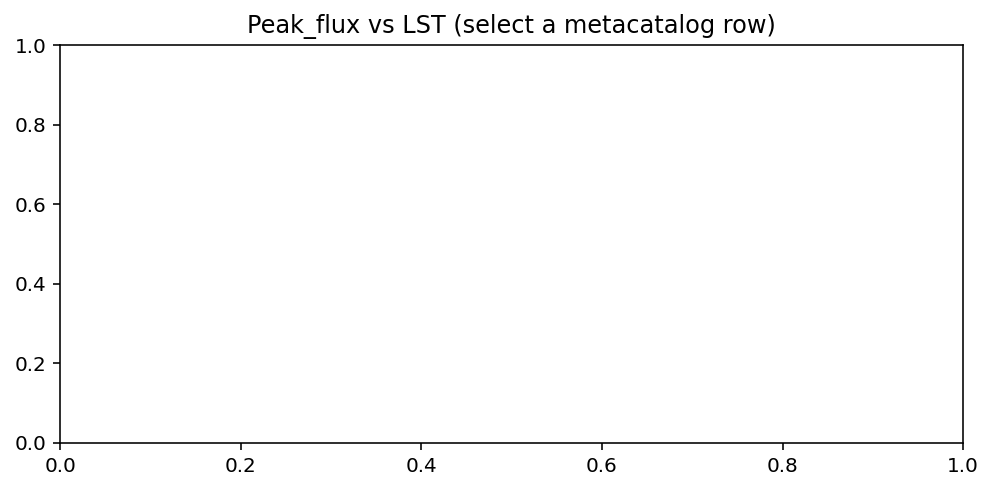
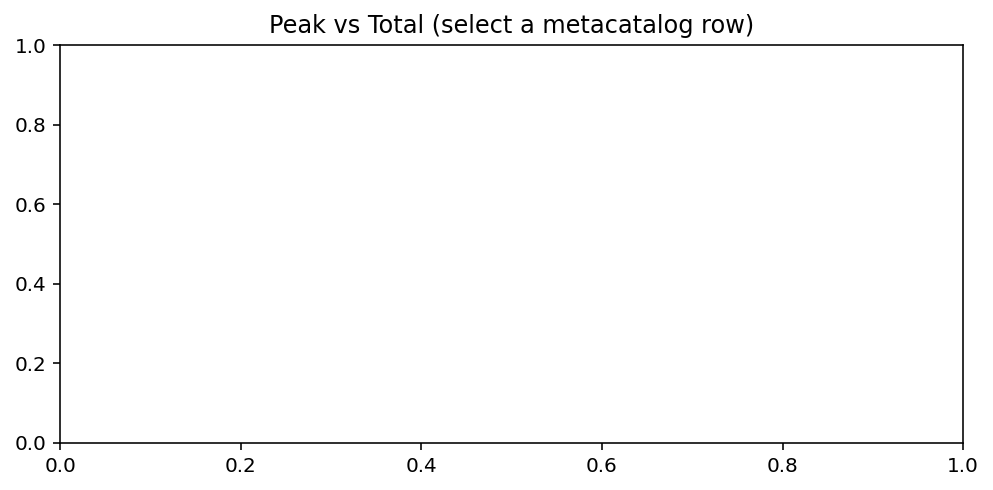
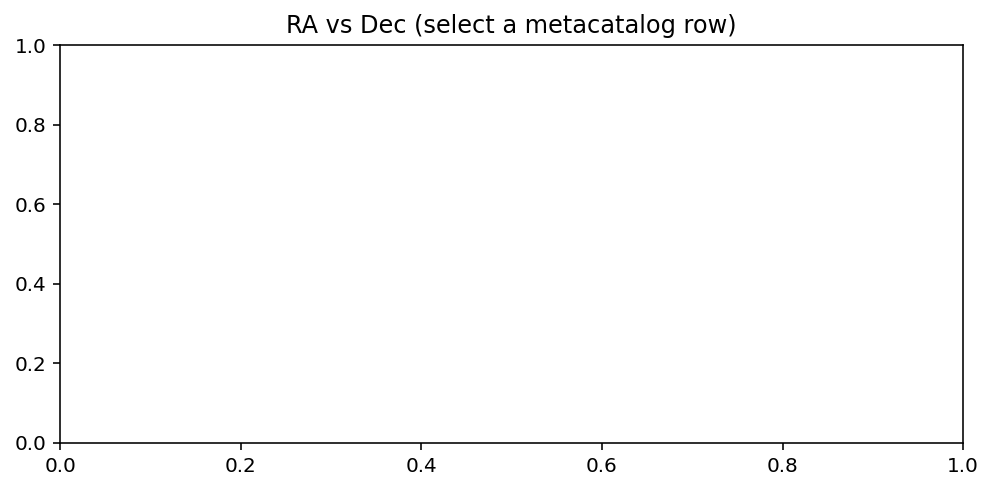
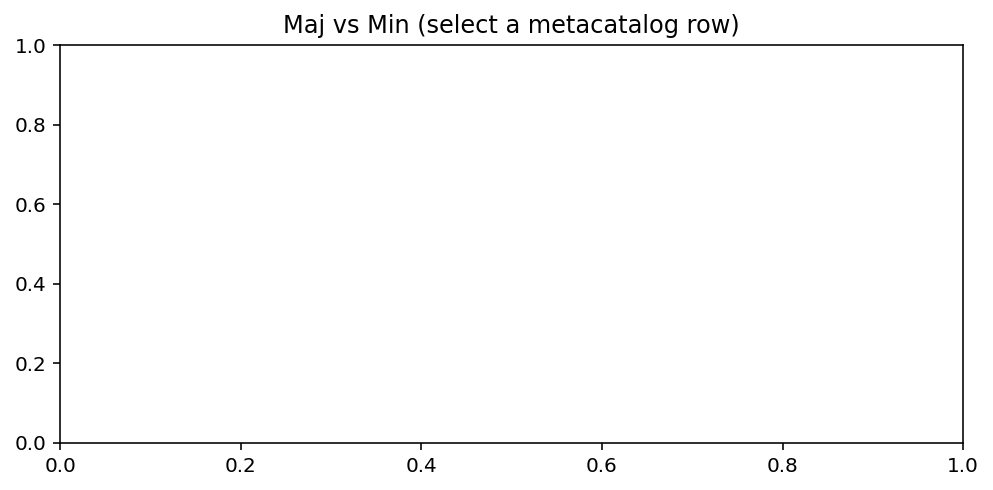

In [3]:
def order_columns(df: pd.DataFrame, *, limit: int | None = MAX_TABLE_COLUMNS) -> list[str]:
    """Return column names in preferred order; optionally truncate for display."""
    preferred = [c for c in _preferred_columns if c in df.columns]
    rest = sorted(c for c in df.columns if c not in preferred)
    cols = preferred + rest
    if limit is not None and len(cols) > limit:
        cols = cols[:limit]
    return cols


def default_display_columns(df: pd.DataFrame) -> list[str]:
    """Columns to show when loading a catalog (saved prefs, else truncated preferred set)."""
    saved = [c for c in _preferred_columns if c in df.columns]
    if saved:
        return saved
    return order_columns(df)



# Numeric header filter "compare" supports ">5", "<=8.1", "!=0", or bare "5" (≥).
# Register it on window.Tabulator before the browser tables are built.
from IPython.display import Javascript, display

_COMPARE_FILTER_INSTALL_JS = r"""
(function () {
  function install(T) {
    if (!T || T.__lwaCompareFilter) return !!T;
    T.__lwaCompareFilter = true;
    T.extendModule("filter", "filters", {
      compare: function (headerValue, rowValue, rowData, filterParams) {
        if (headerValue === null || headerValue === undefined || headerValue === '') {
          return true;
        }
        if (rowValue === null || rowValue === undefined || rowValue === '') {
          return false;
        }
        var s = String(headerValue).trim();
        var m = s.match(/^(<=|>=|<|>|!=|==|=)?\s*([+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?)\s*$/);
        if (!m) {
          return true; // incomplete while typing
        }
        var op = m[1] || '>=';
        if (op === '==') op = '=';
        var thr = parseFloat(m[2]);
        var v = Number(rowValue);
        if (Number.isNaN(v) || Number.isNaN(thr)) return false;
        switch (op) {
          case '>':  return v > thr;
          case '>=': return v >= thr;
          case '<':  return v < thr;
          case '<=': return v <= thr;
          case '!=': return v !== thr;
          case '=':  return v === thr;
          default:   return v >= thr;
        }
      }
    });
    return true;
  }
  function tryInstall() {
    if (window.Tabulator && install(window.Tabulator)) return true;
    return false;
  }
  if (!tryInstall()) {
    var n = 0;
    var id = setInterval(function () {
      if (tryInstall() || ++n > 400) clearInterval(id);
    }, 25);
  }
  if (window.requirejs) {
    try {
      requirejs(["tabulator"], function (T) { install(T || window.Tabulator); });
    } catch (e) {}
  }
})();
"""

display(Javascript(_COMPARE_FILTER_INSTALL_JS))


def header_filters_for(df: pd.DataFrame) -> dict[str, dict]:
    """Per-column Tabulator header filters (numeric comparisons, text contains)."""
    filters: dict[str, dict] = {}
    for col in df.columns:
        kind = df[col].dtype.kind
        if kind in "iuf":
            filters[col] = {
                "type": "input",
                "func": "compare",
                "placeholder": ">5 / <=8.1",
            }
        elif kind == "b":
            filters[col] = {"type": "tickCross", "tristate": True, "indeterminateValue": None}
        else:
            filters[col] = {"type": "input", "func": "like", "placeholder": "contains…"}
    return filters


def nearest_sources(
    df: pd.DataFrame,
    coord: SkyCoord,
    *,
    n: int = 5,
    ra_col: str = "RA",
    dec_col: str = "DEC",
) -> pd.DataFrame:
    """Return the ``n`` catalog rows closest to ``coord`` (great-circle)."""
    if ra_col not in df.columns or dec_col not in df.columns:
        raise KeyError(f"Need {ra_col!r} and {dec_col!r} columns for sky matching")
    if df.empty:
        raise ValueError("Catalog is empty")

    catalog = SkyCoord(
        ra=np.asarray(df[ra_col], dtype=float) * u.deg,
        dec=np.asarray(df[dec_col], dtype=float) * u.deg,
        frame="icrs",
    )
    seps = coord.separation(catalog)
    order = np.argsort(seps.deg)
    n = max(1, min(int(n), len(df)))
    out = df.iloc[order[:n]].copy()
    out.insert(0, "sep_arcmin", np.round(seps.deg[order[:n]] * 60.0, 4))
    out.insert(1, "sep_deg", np.round(seps.deg[order[:n]], 6))
    # Defragment + isolate from the parent catalog (Tabulator may mutate .value in place).
    return out.reset_index(drop=True).copy()


def _mpl_configure() -> None:
    """Use a non-interactive backend once per kernel (Panel owns display)."""
    import matplotlib

    if matplotlib.get_backend().lower() != "agg":
        matplotlib.use("agg")


def _close_mpl_figure(fig) -> None:
    if fig is None:
        return
    import matplotlib.pyplot as plt

    try:
        plt.close(fig)
    except Exception:
        pass


def _mpl_new_figure(*, figsize: tuple[float, float] = (7.0, 3.5)):
    _mpl_configure()
    import matplotlib.pyplot as plt

    return plt.subplots(figsize=figsize)


def _mpl_empty_figure(title: str):
    """Create a small Agg figure with a title (for empty trace state)."""
    fig, ax = _mpl_new_figure(figsize=(7.0, 3.5))
    ax.set_title(title)
    fig.tight_layout()
    return fig


def _mpl_reset_figure(fig, title: str, *, figsize: tuple[float, float] = (7.0, 3.5)):
    """Clear an existing figure in place (avoids leaking pyplot figure handles)."""
    if fig is None:
        fig, ax = _mpl_new_figure(figsize=figsize)
    else:
        fig.clf()
        ax = fig.add_subplot(111)
    ax.set_title(title)
    fig.tight_layout()
    return fig


def _set_mpl_pane(pane, fig) -> None:
    """Assign a Matplotlib pane figure and close any replaced handle."""
    old = pane.object
    if old is fig:
        pane.param.trigger("object")
        return
    pane.object = fig
    _close_mpl_figure(old)


def _mpl_placeholder(pane, title: str) -> None:
    fig = _mpl_reset_figure(pane.object, title)
    _set_mpl_pane(pane, fig)


def _mpl_trace_figures(
    source_matches: pd.DataFrame,
    figures: tuple | None = None,
):
    """Build consistency figures (flux, RA/Dec, Maj/Min) for Panel."""
    _mpl_configure()
    import matplotlib.pyplot as plt

    from lwa_catalog.analyze import (
        plot_maj_min_scatter,
        plot_member_property_scatter,
        plot_peak_flux_vs_lst,
        plot_ra_dec_scatter,
    )

    def _axis(i: int, figsize: tuple[float, float]):
        if figures is not None and i < len(figures) and figures[i] is not None:
            fig = figures[i]
            fig.clf()
            return fig, fig.add_subplot(111)
        return plt.subplots(figsize=figsize)

    fig1, ax1 = _axis(0, (6.5, 3.4))
    plot_peak_flux_vs_lst(source_matches, ax=ax1)
    fig1.tight_layout()

    fig2, ax2 = _axis(1, (6.5, 3.4))
    plot_member_property_scatter(source_matches, ax=ax2)
    fig2.tight_layout()

    fig3, ax3 = _axis(2, (6.5, 3.4))
    plot_ra_dec_scatter(source_matches, ax=ax3)
    fig3.tight_layout()

    fig4, ax4 = _axis(3, (6.5, 3.4))
    plot_maj_min_scatter(source_matches, ax=ax4)
    fig4.tight_layout()
    return fig1, fig2, fig3, fig4


def browser_fetch_hips_surveys() -> list[str]:
    """HiPS survey list (remote list server with local ``CATALOG_DIR`` fallback)."""
    return fetch_hips_surveys(
        HIPS_LIST_SERVER,
        catalog_dir=CATALOG_DIR,
        default_survey=DEFAULT_HIPS_SURVEY,
    )


class CatalogBrowser(pn.viewable.Viewer):
    """Interactive browser for Parquet catalogs under ``CATALOG_DIR``."""

    kind = param.Selector(default="all", objects=["all"], doc="Artifact kind filter")
    lst_hour = param.Selector(default="all", objects=["all"], doc="LST hour filter")
    band = param.Selector(default="all", objects=["all"], doc="Band filter")
    catalog_file = param.Selector(default="", objects=[""], doc="Selected Parquet file")
    display_columns = param.ListSelector(
        default=[],
        objects=[],
        doc="Columns shown in the browse and nearest-source tables",
    )
    coordinate = param.String(
        default="83.633 -5.391",
        doc="Query coordinate (decimal deg or sexagesimal)",
    )
    n_nearest = param.Integer(default=DEFAULT_N_NEAREST, bounds=(1, 50), doc="Neighbors to return")
    meta_id = param.Integer(default=0, bounds=(0, None), doc="Metacatalog meta_id to rematch")
    show_overlay = param.Boolean(default=True, doc="Draw catalog sources on the HiPS view")
    max_sources = param.Integer(
        default=OVERLAY_MAX_SOURCES_DEFAULT,
        bounds=OVERLAY_MAX_SOURCES_BOUNDS,
        doc="Max sources drawn inside the current FOV",
    )

    def __init__(self, index: pd.DataFrame, **params):
        # Validate Selector values only after objects lists are populated.
        params = dict(params)
        params.pop("kind", None)
        params.pop("lst_hour", None)
        params.pop("band", None)
        params.pop("catalog_file", None)
        params.pop("display_columns", None)
        super().__init__(**params)

        self._ready = False
        self._index = index.copy()
        self._df: pd.DataFrame | None = None
        self._nearest_hits: pd.DataFrame | None = None
        self._trace = None
        self._overlay_refresh: DebouncedAladinViewRefresh | None = None
        self._layout = CatalogLayout(CATALOG_DIR)
        self._status = pn.pane.Markdown("", sizing_mode="stretch_width")
        self._nearest_status = pn.pane.Markdown("", sizing_mode="stretch_width")
        self._trace_status = pn.pane.Markdown(
            "_Load **metacatalog.parquet** and click a row to rematch members._",
            sizing_mode="stretch_width",
        )

        kinds = ["all", *sorted(str(x) for x in index["kind"].dropna().unique())]
        self.param.kind.objects = kinds

        with pn.config.set(sizing_mode="stretch_width"):
            self._kind_w = pn.widgets.Select.from_param(self.param.kind, name="Kind")
            self._lst_w = pn.widgets.Select.from_param(self.param.lst_hour, name="LST hour")
            self._band_w = pn.widgets.Select.from_param(self.param.band, name="Band")
            self._file_w = pn.widgets.Select.from_param(self.param.catalog_file, name="Catalog file")
            self._cols_w = pn.widgets.MultiChoice.from_param(
                self.param.display_columns,
                name="Display columns",
                placeholder="Select columns to show…",
                solid=False,
                option_limit=80,
                search_option_limit=80,
            )
            self._save_cols_btn = pn.widgets.Button(
                name="Save as default",
                button_type="default",
                width=140,
                sizing_mode="fixed",
            )
            self._save_cols_btn.on_click(self._on_save_columns)
            self._coord_w = pn.widgets.TextInput.from_param(
                self.param.coordinate, name="Coordinate", placeholder="RA Dec"
            )
            self._n_w = pn.widgets.IntInput.from_param(self.param.n_nearest, name="N nearest")
            self._find_btn = pn.widgets.Button(name="Find nearest", button_type="primary")
            self._find_btn.on_click(self._on_find_nearest)

            self._table = pn.widgets.Tabulator(
                pd.DataFrame(),
                pagination="local",
                page_size=TABLE_PAGE_SIZE,
                height=TABLE_HEIGHT,
                sizing_mode="stretch_width",
                layout="fit_data_table",
                header_filters={},
                show_index=False,
                disabled=True,
                sortable=True,
                selectable=1,
            )
            self._table.param.watch(self._on_table_select, "selection")

            self._nearest_table = pn.widgets.Tabulator(
                pd.DataFrame(),
                pagination=None,
                height=220,
                sizing_mode="stretch_width",
                layout="fit_data_table",
                show_index=False,
                disabled=True,
                sortable=True,
            )

            self._lst_trace_table = pn.widgets.Tabulator(
                pd.DataFrame(),
                pagination=None,
                height=180,
                sizing_mode="stretch_width",
                layout="fit_data_table",
                show_index=False,
                disabled=True,
                sortable=True,
            )
            self._src_trace_table = pn.widgets.Tabulator(
                pd.DataFrame(),
                pagination="local",
                page_size=25,
                height=260,
                sizing_mode="stretch_width",
                layout="fit_data_table",
                show_index=False,
                disabled=True,
                sortable=True,
            )
            self._meta_id_w = pn.widgets.IntInput.from_param(
                self.param.meta_id, name="meta_id", width=140
            )
            self._trace_btn = pn.widgets.Button(
                name="Trace meta_id",
                button_type="primary",
                width=140,
                sizing_mode="fixed",
            )
            self._trace_btn.on_click(self._on_trace_meta_id)

            hips_surveys = browser_fetch_hips_surveys()
            hips_default = default_hips_survey(
                hips_surveys,
                default_survey=DEFAULT_HIPS_SURVEY,
            )
            init_coord = parse_coordinate(self.coordinate)

            from ipyaladin import Aladin

            self._overlay_w = pn.widgets.Checkbox.from_param(
                self.param.show_overlay,
                name="Show catalog overlay",
            )
            self._max_sources_w = pn.widgets.IntInput.from_param(
                self.param.max_sources,
                name="Max sources in view",
                width=160,
            )
            self._hips_survey_w = pn.widgets.Select(
                name="HiPS survey",
                options=hips_surveys,
                value=hips_default,
                sizing_mode="stretch_width",
            )
            self._hips_fov_w = pn.widgets.FloatSlider(
                name="FOV (deg)",
                start=0.05,
                end=5.0,
                value=SKY_FOV_DEG,
                step=0.05,
            )
            self._hips_status = pn.pane.Markdown(
                "_Select a catalog row to center the sky view._",
                sizing_mode="stretch_width",
            )
            self._overlay_status = pn.pane.Markdown("", sizing_mode="stretch_width")
            self._save_sky_btn = pn.widgets.Button(
                name="Save sky PNG",
                button_type="default",
                width=140,
                sizing_mode="fixed",
            )
            self._save_sky_btn.on_click(self._on_save_sky_png)
            self._hips_current_survey = hips_survey_url(hips_default, base=HIPS_SERVER)
            self._aladin = Aladin(
                survey=self._hips_current_survey,
                target=init_coord,
                fov=SKY_FOV_DEG,
                height=HIPS_VIEW_HEIGHT,
            )
            self._hips_view = pn.pane.IPyWidget(
                self._aladin,
                height=HIPS_VIEW_HEIGHT + 20,
                sizing_mode="stretch_width",
            )
            self._overlay_refresh = DebouncedAladinViewRefresh(
                self._aladin,
                self._refresh_overlay_from_aladin,
                enabled=lambda: self._ready and self.show_overlay,
            )
            self._hips_survey_w.param.watch(self._on_hips_survey_change, "value")
            self._hips_fov_w.param.watch(self._on_hips_fov_change, "value")
            self._overlay_w.param.watch(self._on_overlay_change, "value")
            self._max_sources_w.param.watch(self._on_max_sources_change, "value")

            empty1 = _mpl_empty_figure("Peak_flux vs LST (select a metacatalog row)")
            empty2 = _mpl_empty_figure("Peak vs Total (select a metacatalog row)")
            empty3 = _mpl_empty_figure("RA vs Dec (select a metacatalog row)")
            empty4 = _mpl_empty_figure("Maj vs Min (select a metacatalog row)")
            self._flux_plot = pn.pane.Matplotlib(empty1, tight=True, height=320)
            self._scatter_plot = pn.pane.Matplotlib(empty2, tight=True, height=320)
            self._radec_plot = pn.pane.Matplotlib(empty3, tight=True, height=320)
            self._majmin_plot = pn.pane.Matplotlib(empty4, tight=True, height=320)

            self._panel = pn.Column(
                pn.Row(self._kind_w, self._lst_w, self._band_w),
                self._file_w,
                pn.Row(self._cols_w, self._save_cols_btn),
                self._status,
                self._table,
                pn.pane.Markdown(
                    "### Source trace (rematch)\n"
                    "Click a **metacatalog** row above, or enter a `meta_id` and click "
                    "**Trace meta_id**. Rematch uses beam association and keeps the "
                    "highest-elevation seed; durable key `(band, lst_hour, Source_id)`.",
                    disable_anchors=True,
                ),
                pn.Row(self._meta_id_w, self._trace_btn),
                self._trace_status,
                pn.pane.Markdown("#### LST-merged matches", disable_anchors=True),
                self._lst_trace_table,
                pn.pane.Markdown("#### Per-hour source matches", disable_anchors=True),
                self._src_trace_table,
                pn.Row(self._flux_plot, self._scatter_plot),
                pn.Row(self._radec_plot, self._majmin_plot),
                pn.pane.Markdown("### Nearest-source query", disable_anchors=True),
                pn.Row(self._coord_w, self._n_w, self._find_btn),
                self._nearest_status,
                self._nearest_table,
                pn.pane.Markdown("### Sky context (HiPS + catalog overlay)", disable_anchors=True),
                pn.Row(self._hips_survey_w, self._hips_fov_w),
                pn.Row(self._overlay_w, self._max_sources_w, self._save_sky_btn),
                self._hips_status,
                self._overlay_status,
                self._hips_view,
            )

        self._ready = True
        self.kind = "metacatalog" if "metacatalog" in kinds else "all"
        self._sync_filters()
        self._load_selected()

    def __panel__(self):
        return self._panel

    def select_file(self, filename: str) -> None:
        """Select a catalog by filename (updates kind / LST / band filters)."""
        rows = self._index.loc[self._index["file"] == filename]
        if rows.empty:
            raise KeyError(f"Unknown catalog file: {filename}")
        row = rows.iloc[0]
        kind = str(row["kind"])
        if kind not in self.param.kind.objects:
            self.param.kind.objects = ["all", *sorted(set(self.param.kind.objects) | {kind})]
        self.kind = kind
        self._sync_filters()
        if filename not in self.param.catalog_file.objects:
            self.param.catalog_file.objects = [*self.param.catalog_file.objects, filename]
        self.catalog_file = filename
        self._load_selected()

    def _filtered_index(self) -> pd.DataFrame:
        df = self._index
        if self.kind != "all":
            df = df[df["kind"] == self.kind]
        if self.lst_hour != "all":
            df = df[df["lst_hour"] == self.lst_hour]
        if self.band != "all":
            df = df[df["band"] == self.band]
        return df

    def _is_metacatalog(self) -> bool:
        if self._df is None or self._df.empty:
            return False
        if "meta_id" not in self._df.columns:
            return False
        name = str(self.catalog_file)
        return name == "metacatalog.parquet" or self.kind == "metacatalog"

    @param.depends("kind", watch=True, on_init=False)
    def _on_kind_change(self) -> None:
        if not getattr(self, "_ready", False):
            return
        self._sync_filters()

    @param.depends("lst_hour", "band", watch=True, on_init=False)
    def _on_subfilter_change(self) -> None:
        if not getattr(self, "_ready", False):
            return
        self._sync_file_options(reset_if_missing=True)

    @param.depends("catalog_file", watch=True, on_init=False)
    def _on_file_change(self) -> None:
        if not getattr(self, "_ready", False):
            return
        self._load_selected()

    @param.depends("display_columns", watch=True, on_init=False)
    def _on_columns_change(self) -> None:
        if not getattr(self, "_ready", False):
            return
        self._apply_display_columns()

    def _sync_filters(self) -> None:
        base = self._index if self.kind == "all" else self._index[self._index["kind"] == self.kind]
        lst_opts = ["all", *sorted(str(x) for x in base["lst_hour"].dropna().unique())]
        band_opts = ["all", *sorted(str(x) for x in base["band"].dropna().unique())]
        self.param.lst_hour.objects = lst_opts
        self.param.band.objects = band_opts
        if self.lst_hour not in lst_opts:
            self.lst_hour = "all"
        if self.band not in band_opts:
            self.band = "all"
        self._sync_file_options(reset_if_missing=True)

    def _sync_file_options(self, *, reset_if_missing: bool) -> None:
        files = self._filtered_index()["file"].tolist() or [""]
        self.param.catalog_file.objects = files
        if files == [""]:
            self.catalog_file = ""
            return
        if reset_if_missing and self.catalog_file not in files:
            preferred = ["metacatalog.parquet"]
            preferred += [f for f in files if f.endswith("_Full.parquet")]
            self.catalog_file = next((f for f in preferred if f in files), files[0])

    def _set_table_value(self, table: pn.widgets.Tabulator, df: pd.DataFrame) -> None:
        """Assign a defensive copy so Tabulator cannot mutate catalog/hit frames."""
        safe = df.reset_index(drop=True).copy()
        new_cols = list(safe.columns)
        old = table.value
        old_cols = list(old.columns) if old is not None else None
        # When columns change on a table that already had columns, clear first so
        # Panel/Tabulator does not reuse CDS buffers (wrong/blank cells).
        # Skip the clear when the old table was columnless — an empty intermediate
        # update can leave the nearest-source grid stuck blank in the browser.
        if old_cols is not None and old_cols != new_cols and len(old_cols) > 0:
            table.value = safe.iloc[:0].copy()
        if table is self._table:
            table.header_filters = header_filters_for(safe) if new_cols else {}
        table.value = safe

    def _selected_columns(self) -> list[str]:
        """Ordered intersection of the user's column picks with the loaded table."""
        if self._df is None:
            return []
        available = set(self._df.columns)
        chosen = [c for c in self.display_columns if c in available]
        if not chosen:
            return default_display_columns(self._df)
        # Keep preferred ordering among the selected set
        return [c for c in order_columns(self._df, limit=None) if c in set(chosen)]

    def _apply_nearest_columns(self) -> None:
        if self._nearest_hits is None or self._nearest_hits.empty:
            self._set_table_value(self._nearest_table, pd.DataFrame())
            return
        cols = ["sep_arcmin", "sep_deg", *self._selected_columns()]
        cols = [c for c in cols if c in self._nearest_hits.columns]
        self._set_table_value(self._nearest_table, self._nearest_hits.loc[:, cols])

    def _apply_display_columns(self) -> None:
        if self._df is None:
            self._set_table_value(self._table, pd.DataFrame())
            self._apply_nearest_columns()
            return
        cols = self._selected_columns()
        self._set_table_value(self._table, self._df.loc[:, cols])
        skipped = len(self._df.columns) - len(cols)
        extra = f" (showing {len(cols)}/{len(self._df.columns)} columns)" if skipped else ""
        hint = ""
        if self._is_metacatalog():
            hint = " Click a row for source trace."
        self._status.object = (
            f"**{self.catalog_file}** — {len(self._df):,} rows × {len(self._df.columns)} columns{extra}. "
            "Click headers to sort; numeric filters: `>5`, `<=8.1`, or bare `5` (≥)."
            f"{hint}"
        )
        self._apply_nearest_columns()

    def close_mpl_figures(self) -> None:
        """Close trace Matplotlib figures (call before discarding this browser)."""
        for pane in (
            self._flux_plot,
            self._scatter_plot,
            self._radec_plot,
            self._majmin_plot,
        ):
            _close_mpl_figure(pane.object)
            pane.object = None

    def _clear_trace(self, message: str) -> None:
        self._trace = None
        clear_trace_overlays(self._aladin)
        self._trace_status.object = message
        self._set_table_value(self._lst_trace_table, pd.DataFrame())
        self._set_table_value(self._src_trace_table, pd.DataFrame())
        for pane, title in (
            (self._flux_plot, "Peak_flux vs LST (select a metacatalog row)"),
            (self._scatter_plot, "Peak vs Total (select a metacatalog row)"),
            (self._radec_plot, "RA vs Dec (select a metacatalog row)"),
            (self._majmin_plot, "Maj vs Min (select a metacatalog row)"),
        ):
            _mpl_placeholder(pane, title)

    def _load_selected(self) -> None:
        self._table.selection = []
        if not self.catalog_file:
            self._df = None
            self._nearest_hits = None
            self.param.display_columns.objects = []
            self.display_columns = []
            self._set_table_value(self._table, pd.DataFrame())
            self._set_table_value(self._nearest_table, pd.DataFrame())
            self._status.object = "_No catalog matches the current filters._"
            self._nearest_status.object = ""
            self._clear_trace("_Load **metacatalog.parquet** and click a row to rematch members._")
            try:
                self._refresh_overlay()
            except Exception:
                pass
            return

        path = CATALOG_DIR / self.catalog_file
        df = read_table(path, as_pandas=True)
        self._df = df
        self._nearest_hits = None
        all_cols = order_columns(df, limit=None)
        kept = [c for c in self.display_columns if c in all_cols]
        self.param.display_columns.objects = all_cols
        self.display_columns = kept if kept else default_display_columns(df)
        self._apply_display_columns()
        self._nearest_status.object = ""
        self._refresh_overlay()
        if self._is_metacatalog():
            self._clear_trace("_Click a metacatalog row to rematch LST / sources members._")
        else:
            self._clear_trace(
                "_Source trace is available when browsing **metacatalog.parquet** "
                "(select Kind = metacatalog)._"
            )


    def _row_sky_coord(self, row: pd.Series) -> SkyCoord | None:
        if "RA" not in row.index or "DEC" not in row.index:
            return None
        if pd.isna(row["RA"]) or pd.isna(row["DEC"]):
            return None
        return SkyCoord(
            ra=float(row["RA"]) * u.deg,
            dec=float(row["DEC"]) * u.deg,
            frame="icrs",
        )

    def _apply_row_coordinate(self, row: pd.Series) -> None:
        coord = self._row_sky_coord(row)
        if coord is None:
            return
        self.coordinate = format_coordinate_deg(coord.ra.deg, coord.dec.deg)
        self._update_sky_view(row)

    def _overlay_selection_idx(self) -> int | None:
        if not self._table.selection or self._df is None:
            return None
        idx = int(self._table.selection[0])
        if 0 <= idx < len(self._df):
            return idx
        return None

    def _refresh_overlay(
        self,
        coord: SkyCoord | None = None,
        *,
        fov_deg: float | None = None,
    ) -> None:
        if coord is None or fov_deg is None:
            view_coord, view_fov = aladin_view_center_fov(self._aladin)
            coord = coord or view_coord
            fov_deg = fov_deg if fov_deg is not None else view_fov

        catalog_name = catalog_name_from_file(self.catalog_file or "catalog")
        fov = float(fov_deg)

        if not self.show_overlay:
            overlay_catalog_by_band(
                self._aladin,
                pd.DataFrame(),
                catalog_name,
                coord,
                fov,
                replace=True,
            )
            clear_trace_overlays(self._aladin)
            self._overlay_status.object = "_Catalog overlay off._"
            return

        if self._df is None or self._df.empty:
            overlay_catalog_by_band(
                self._aladin,
                pd.DataFrame(),
                catalog_name,
                coord,
                fov,
                replace=True,
            )
            clear_trace_overlays(self._aladin)
            self._overlay_status.object = "_Load a catalog to draw overlays._"
            return

        result = overlay_catalog_by_band(
            self._aladin,
            self._df,
            catalog_name,
            coord,
            fov,
            max_rows=int(self.max_sources),
            selection_idx=self._overlay_selection_idx(),
        )
        cap_note = f" (capped at {self.max_sources})" if result.truncated else ""
        trace_note = ""
        if self._trace is not None:
            trace_results = overlay_trace_members(
                self._aladin,
                self._trace.lst_matches,
                self._trace.source_matches,
                coord,
                fov,
                catalog_name="metacatalog",
                max_rows=int(self.max_sources),
            )
            parts = []
            if "trace_lst" in trace_results:
                parts.append(f"LST {trace_results['trace_lst'].drawn}")
            if "trace_src" in trace_results:
                parts.append(f"sources {trace_results['trace_src'].drawn}")
            if parts:
                trace_note = f"; trace overlay: {', '.join(parts)}"
        else:
            clear_trace_overlays(self._aladin)

        self._overlay_status.object = (
            f"**Overlay:** {result.drawn} drawn, {result.in_fov} in FOV{cap_note} "
            f"— `{self.catalog_file}`{trace_note}."
        )

    def _refresh_overlay_from_aladin(self) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._overlay_status.object = f"**Overlay refresh failed:** `{exc}`"

    def _on_overlay_change(self, _event=None) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._overlay_status.object = f"**Overlay refresh failed:** `{exc}`"

    def _on_max_sources_change(self, _event=None) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._overlay_status.object = f"**Overlay refresh failed:** `{exc}`"

    def _on_save_sky_png(self, _event=None) -> None:
        """Save the current HiPS view via ipyaladin (quick QA screenshot)."""
        SKY_SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)
        stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        path = SKY_SCREENSHOT_DIR / f"query_sky_{stamp}.png"
        try:
            self._aladin.save_view_as_image(path, image_format="png", with_logo=True)
        except Exception as exc:
            self._hips_status.object = f"**Save sky PNG failed:** `{exc}`"
            return
        self._hips_status.object = f"Saved sky view → `{path}`"

    def _set_hips_survey(self, survey_name: str) -> None:
        """Switch HiPS layer only when the survey selection changes."""
        url = hips_survey_url(survey_name, base=HIPS_SERVER)
        if url == self._hips_current_survey:
            return
        self._aladin.survey = url
        self._hips_current_survey = url

    def _update_sky_view(self, row: pd.Series, *, refresh_widget: bool = False) -> None:
        coord = self._row_sky_coord(row)
        if coord is None:
            return
        self._set_hips_survey(str(self._hips_survey_w.value))
        self._aladin.target = coord
        self._aladin.fov = float(self._hips_fov_w.value)
        if refresh_widget:
            # Panel Matplotlib/trace updates can blank ipyaladin's WebGL canvas.
            self._hips_view.object = self._aladin
        label = ""
        if "meta_id" in row.index and pd.notna(row.get("meta_id")):
            label = f"**meta_id={int(row['meta_id'])}** — "
        self._hips_status.object = (
            f"{label}Centered on RA={coord.ra.deg:.6f}, Dec={coord.dec.deg:.6f} "
            f"(FOV={self._hips_fov_w.value:.2f}°)."
        )
        self._refresh_overlay(coord, fov_deg=float(self._hips_fov_w.value))

    def _refresh_sky_view(self) -> None:
        """Re-center HiPS after heavy Panel sibling updates (e.g. trace plots)."""
        if not self._table.selection or self._df is None:
            return
        idx = int(self._table.selection[0])
        if 0 <= idx < len(self._df):
            self._update_sky_view(self._df.iloc[idx], refresh_widget=True)

    def _on_hips_survey_change(self, _event=None) -> None:
        self._set_hips_survey(str(self._hips_survey_w.value))
        self._refresh_sky_view()
        try:
            self._refresh_overlay()
        except Exception:
            pass

    def _on_hips_fov_change(self, _event=None) -> None:
        self._aladin.fov = float(self._hips_fov_w.value)
        if not self._table.selection or self._df is None:
            try:
                self._refresh_overlay()
            except Exception:
                pass
            return
        idx = int(self._table.selection[0])
        if 0 <= idx < len(self._df):
            coord = self._row_sky_coord(self._df.iloc[idx])
            if coord is not None:
                self._aladin.target = coord
        try:
            self._refresh_overlay()
        except Exception:
            pass

    def _on_table_select(self, _event=None) -> None:
        if not getattr(self, "_ready", False):
            return
        if not self._table.selection:
            return
        if self._df is None:
            return
        idx = int(self._table.selection[0])
        if idx < 0 or idx >= len(self._df):
            if self._is_metacatalog():
                self._trace_status.object = f"**Selection index {idx} out of range.**"
            return
        row = self._df.iloc[idx]
        self._apply_row_coordinate(row)

        if not self._is_metacatalog():
            return
        if "meta_id" not in row.index or pd.isna(row["meta_id"]):
            self._trace_status.object = "**Selected row has no meta_id.**"
            return
        mid = int(row["meta_id"])
        self.meta_id = mid
        self._run_trace(mid)

    def _on_trace_meta_id(self, _event=None) -> None:
        self._run_trace(int(self.meta_id))

    def _metacatalog_frame(self) -> pd.DataFrame:
        """Return the loaded metacatalog, or read it from ``CATALOG_DIR``."""
        from lwa_catalog.io import read_metacatalog

        if self._is_metacatalog() and self._df is not None:
            return self._df
        return read_metacatalog(self._layout)

    def _run_trace(self, meta_id: int) -> None:
        from lwa_catalog.analyze import preferred_trace_columns, rematch_meta_source

        try:
            meta_df = self._metacatalog_frame()
            trace = rematch_meta_source(meta_df, self._layout, meta_id=meta_id)
        except Exception as exc:
            self._clear_trace(f"**Trace failed for meta_id={meta_id}:** `{exc}`")
            return

        self._trace = trace
        self.meta_id = int(trace.meta_id)
        warn = ""
        if trace.warnings:
            warn = "  \n" + "  \n".join(f"- {w}" for w in trace.warnings)
        n_lst_meta = trace.meta_row.get("n_lst_contributions", "—")
        self._trace_status.object = (
            f"**meta_id={trace.meta_id}** — "
            f"LST matches: {len(trace.lst_matches)}, "
            f"source matches: {len(trace.source_matches)} "
            f"(meta `n_lst_contributions`={n_lst_meta}).{warn}"
        )

        lst_cols = preferred_trace_columns(trace.lst_matches)
        src_cols = preferred_trace_columns(trace.source_matches)
        self._set_table_value(
            self._lst_trace_table,
            trace.lst_matches.loc[:, lst_cols] if lst_cols else trace.lst_matches,
        )
        self._set_table_value(
            self._src_trace_table,
            trace.source_matches.loc[:, src_cols] if src_cols else trace.source_matches,
        )
        self._apply_row_coordinate(trace.meta_row)

        figs = (
            self._flux_plot.object,
            self._scatter_plot.object,
            self._radec_plot.object,
            self._majmin_plot.object,
        )
        fig1, fig2, fig3, fig4 = _mpl_trace_figures(trace.source_matches, figures=figs)
        for pane, fig in (
            (self._flux_plot, fig1),
            (self._scatter_plot, fig2),
            (self._radec_plot, fig3),
            (self._majmin_plot, fig4),
        ):
            _set_mpl_pane(pane, fig)
        self._refresh_sky_view()

    def _on_save_columns(self, _event=None) -> None:
        global _preferred_columns
        cols = self._selected_columns()
        if not cols:
            self._status.object = "**Select at least one display column before saving.**"
            return
        _preferred_columns = list(cols)
        prefs_path = save_display_column_prefs(cols)
        self._status.object = (
            f"**Saved {len(cols)} display columns as default** → `{prefs_path}`. "
            "New catalogs (and future sessions) will start with this set."
        )

    def _on_find_nearest(self, _event=None) -> None:
        if self._df is None or self._df.empty:
            self._nearest_status.object = "**Load a catalog first.**"
            return
        try:
            coord = parse_coordinate(self.coordinate)
            hits = nearest_sources(self._df, coord, n=self.n_nearest)
        except Exception as exc:
            self._nearest_status.object = f"**Query failed:** `{exc}`"
            self._nearest_hits = None
            self._set_table_value(self._nearest_table, pd.DataFrame())
            return

        self._nearest_hits = hits.copy()
        self._apply_nearest_columns()
        nearest = hits.iloc[0]
        self._nearest_status.object = (
            f"Query `{coord.to_string('hmsdms')}` → nearest at "
            f"**{nearest['sep_arcmin']:.3f} arcmin** "
            f"(RA={nearest['RA']:.6f}, Dec={nearest['DEC']:.6f}). "
            f"Showing top {len(hits)}."
        )


_prev_browser = globals().get("_catalog_browser")
if isinstance(_prev_browser, CatalogBrowser):
    _prev_browser.close_mpl_figures()

_catalog_browser = CatalogBrowser(catalog_index)
browser = _catalog_browser


def _on_inventory_select(event) -> None:
    if not inventory_table.selection:
        return
    row = inventory_table.value.iloc[int(inventory_table.selection[0])]
    browser.select_file(str(row["file"]))


inventory_table.param.watch(_on_inventory_select, "selection")
browser
